<a href="https://colab.research.google.com/github/fboldt/aulasml/blob/master/aula14a_introdu%C3%A7%C3%A3o_a_nlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

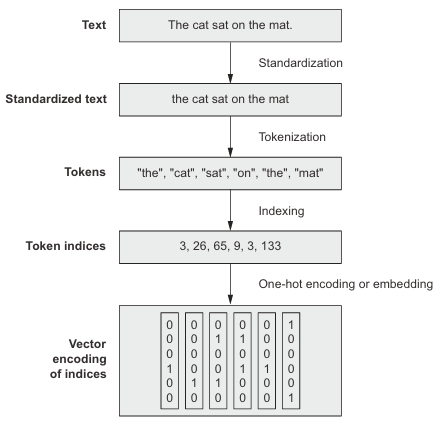

In [1]:
sentence = "I write, erase, rewrite, erase again, and then a poppy blooms!"

In [2]:
import string

def standardize(text):
  text = text.lower()
  return "".join(char for char in text if char not in string.punctuation)

print(standardize(sentence))

i write erase rewrite erase again and then a poppy blooms


In [3]:
def tokenize(text):
  text = standardize(text)
  return text.split()

print(tokenize(sentence))

['i', 'write', 'erase', 'rewrite', 'erase', 'again', 'and', 'then', 'a', 'poppy', 'blooms']


In [4]:
class Vectorizer:
  def standardize(self, text):
    text = text.lower()
    return "".join(char for char in text if char not in string.punctuation)

  def tokenize(self, text):
    text = self.standardize(text)
    return text.split()

  def make_vocabolary(self, dataset):
    self.vocabulary = {"": 0, "[UNK]": 1}
    for text in dataset:
      tokens = self.tokenize(text)
      for token in tokens:
        if token not in self.vocabulary:
          self.vocabulary[token] = len(self.vocabulary)
    self.inverse_vocabulary = dict((v, k) for k, v in self.vocabulary.items())

  def encode(self, text):
    text = self.standardize(text)
    tokens = self.tokenize(text)
    return [self.vocabulary.get(token, 1) for token in tokens]

  def decode(self, int_sequence):
    return " ".join(self.inverse_vocabulary.get(i, "[UNK]") for i in int_sequence)

vectorizer = Vectorizer()

dataset = [
    "I write, erase, rewrite",
    "Erase again, and then",
    "A poppy blooms!",
]

vectorizer.make_vocabolary(dataset)
from pprint import pprint
pprint(vectorizer.vocabulary)

{'': 0,
 '[UNK]': 1,
 'a': 9,
 'again': 6,
 'and': 7,
 'blooms': 11,
 'erase': 4,
 'i': 2,
 'poppy': 10,
 'rewrite': 5,
 'then': 8,
 'write': 3}


In [5]:
test_sentence = "I write, rewrite, and still rewrite again."
encoded_sentence = vectorizer.encode(test_sentence)
decoded_sentence = vectorizer.decode(encoded_sentence)

print(encoded_sentence)
print(decoded_sentence)

[2, 3, 5, 7, 1, 5, 6]
i write rewrite and [UNK] rewrite again


In [6]:
!curl -O https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz
!tar -xf aclImdb_v1.tar.gz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 80.2M  100 80.2M    0     0  3182k      0  0:00:25  0:00:25 --:--:-- 5499k


In [8]:
!rm -r aclImdb/train/unsup

In [9]:
!cat aclImdb/train/pos/4077_10.txt

I first saw this back in the early 90s on UK TV, i did like it then but i missed the chance to tape it, many years passed but the film always stuck with me and i lost hope of seeing it TV again, the main thing that stuck with me was the end, the hole castle part really touched me, its easy to watch, has a great story, great music, the list goes on and on, its OK me saying how good it is but everyone will take there own best bits away with them once they have seen it, yes the animation is top notch and beautiful to watch, it does show its age in a very few parts but that has now become part of it beauty, i am so glad it has came out on DVD as it is one of my top 10 films of all time. Buy it or rent it just see it, best viewing is at night alone with drink and food in reach so you don't have to stop the film.<br /><br />Enjoy

In [10]:
import os
import pandas as pd

def text_dataset_from_directory(directory_path):
  texts = []
  labels = []

  for label in os.listdir(directory_path):
    label_path = os.path.join(directory_path, label)
    if os.path.isdir(label_path):
      for text_file in os.listdir(label_path):
        text_file_path = os.path.join(label_path, text_file)
        if os.path.isfile(text_file_path):
          with open(text_file_path, "r") as f:
            texts.append(f.read())
            labels.append(label)

  return pd.DataFrame({"text": texts, "label": labels})

train_df = text_dataset_from_directory("aclImdb/train")
test_df = text_dataset_from_directory("aclImdb/test")

print(train_df.head())
print(train_df.tail())

                                                text label
0  This movie is about human relationships. Charm...   pos
1  This is a very exciting and romantic film. I h...   pos
2  The primary aspect of this film which most peo...   pos
3  This film is underrated. I loved it. It was tr...   pos
4  *some spoilers*<br /><br />I was pleasantly su...   pos
                                                    text label
24995  Flat, soulless computer images on less than as...   neg
24996  This movie feels so EMPTY. IN every scene in t...   neg
24997  This movie makes several mistakes. a few Ameri...   neg
24998  Basically this is an overlong, unfunny, action...   neg
24999  DeNiro is a master...one of my favourites. And...   neg


In [31]:
from sklearn.base import BaseEstimator, TransformerMixin
from scipy.sparse import csr_matrix

class UnigramTransformer(BaseEstimator, TransformerMixin):
  def __init__(self, max_features=10000):
    self.max_features = max_features
    self.vocabulary = {}
    self.inversed_vocabulary = {}

  def standardize(self, text):
    text = text.lower()
    return "".join(char for char in text if char not in string.punctuation)

  def tokenize(self, text):
    text = self.standardize(text)
    return text.split()

  def fit(self, X, y=None):
    self.vocabulary = {"": 0, "[UNK]": 1}
    for text in X:
      for token in set(self.tokenize(text)):
        if token not in self.vocabulary and len(self.vocabulary) < self.max_features:
          self.vocabulary[token] = len(self.vocabulary)
      if len(self.vocabulary) == self.max_features:
        break
    self.inverse_vocabulary = dict((v, k) for k, v in self.vocabulary.items())
    return self

  def transform(self, X, y=None):
    rows, cols, data = [], [], []
    for row, text in enumerate(X):
      tokens = set(self.tokenize(text))
      for token in tokens:
        rows.append(row)
        cols.append(self.vocabulary.get(token, 1))
        data.append(1)
    return csr_matrix((data, (rows, cols)), shape=(len(X), len(self.vocabulary)))

  def get_feature_names_out(self):
    return list(self.inverse_vocabulary.values())

docs = [
    "The cat sat on the mat.",
    "The dog chased the cat.",
    "Dogs and cats are friends.",
    "The book is on the table.",
    "The cat sat on the book.",
]

unigram_transformer = UnigramTransformer(max_features=10)
unigrams = unigram_transformer.fit_transform(docs)
print(unigram_transformer.get_feature_names_out())
pprint(unigrams.toarray())

['', '[UNK]', 'mat', 'cat', 'the', 'on', 'sat', 'dog', 'chased', 'and']
array([[0, 0, 1, 1, 1, 1, 1, 0, 0, 0],
       [0, 0, 0, 1, 1, 0, 0, 1, 1, 0],
       [0, 4, 0, 0, 0, 0, 0, 0, 0, 1],
       [0, 3, 0, 0, 1, 1, 0, 0, 0, 0],
       [0, 1, 0, 1, 1, 1, 1, 0, 0, 0]])


In [20]:
from sklearn.model_selection import train_test_split

full_train_df = train_df.copy()
train_df, val_df = train_test_split(train_df, test_size=0.2, random_state=42)

train_df.reset_index(drop=True, inplace=True)
val_df.reset_index(drop=True, inplace=True)
test_df.reset_index(drop=True, inplace=True)

print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(20000, 2)
(5000, 2)
(25000, 2)


In [30]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

unigram_pipeline = Pipeline([
    ("vectorizer", UnigramTransformer(10000)),
    ("classifier", RandomForestClassifier(random_state=42)),
])

unigram_pipeline.fit(train_df["text"], train_df["label"])
unigram_pipeline.score(val_df["text"], val_df["label"])

0.832

In [33]:
from math import log

class TfidfTransformer(BaseEstimator, TransformerMixin):
  def __init__(self, max_features=10000):
    self.max_features = max_features
    self.vocabulary = {}
    self.inversed_vocabulary = {}
    self.idf = {}

  def standardize(self, text):
    text = text.lower()
    return "".join(char for char in text if char not in string.punctuation)

  def tokenize(self, text):
    text = self.standardize(text)
    return text.split()

  def fit(self, X, y=None):
    df = {}
    total_docs = len(X)
    for doc in X:
      tokens = set(self.tokenize(doc))
      for token in tokens:
        df[token] = df.get(token, 0) + 1
    # Sort by frequency
    sorted_tokens = sorted(df.items(), key=lambda x: x[1], reverse=True)
    # Limit features
    sorted_tokens = sorted_tokens[:self.max_features]
    self.vocabulary = {}
    # Create vocabulary
    for i, (token, _) in enumerate(sorted_tokens):
      self.vocabulary[token] = i + 2
    # Inverse vocabulary
    self.inversed_vocabulary = {v: k for k, v in self.vocabulary.items()}
    # Compute IDF
    for token, freq in self.vocabulary.items():
      self.idf[self.vocabulary[token]] = log(total_docs / freq)
    self.vocabulary[""] = 0
    self.inversed_vocabulary[0] = ""
    self.vocabulary["[UNK]"] = 1
    self.inversed_vocabulary[1] = "[UNK]"
    return self

  def transform(self, X, y=None):
    rows, cols, data = [], [], []
    for row, doc in enumerate(X):
      tokens = self.tokenize(doc)
      total_terms = len(tokens)
      tf_counts = {}
      for token in tokens:
        if token in self.vocabulary:
          tf_counts[token] = tf_counts.get(token, 0) + 1
      for token, freq in tf_counts.items():
        tf = freq / total_terms
        value = tf * self.idf[self.vocabulary[token]]
        data.append(value)
        rows.append(row)
        cols.append(self.vocabulary[token])
    return csr_matrix((data, (rows, cols)), shape=(len(X), len(self.vocabulary)))

  def get_feature_names_out(self):
    return list(self.inversed_vocabulary.values())

docs = [
    "The cat sat on the mat.",
    "The dog chased the cat.",
    "Dogs and cats are friends.",
    "The book is on the table.",
    "The cat sat on the book.",
]

tfidf_transformer = TfidfTransformer(max_features=10)
tfidfs = tfidf_transformer.fit_transform(docs)
print(tfidf_transformer.get_feature_names_out())
pprint(tfidfs.toarray())

['the', 'cat', 'on', 'sat', 'book', 'mat', 'dog', 'chased', 'and', 'dogs', '', '[UNK]']
array([[ 0.        ,  0.        ,  0.30543024,  0.0851376 ,  0.03719059,
         0.        ,  0.        , -0.05607871,  0.        ,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.36651629,  0.10216512,  0.        ,
         0.        ,  0.        ,  0.        , -0.09400073, -0.11755733,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        -0.13862944, -0.15769147],
       [ 0.        ,  0.        ,  0.30543024,  0.        ,  0.03719059,
         0.        , -0.03038693,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.30543024,  0.0851376 ,  0.03719059,
         0.        , -0.03038693,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ]])


In [35]:
tfidf_transformer.vocabulary["[UNK]"]

1

In [37]:
tfidf_pipeline = Pipeline([
    ("vectorizer", TfidfTransformer(10000)),
    ("classifier", RandomForestClassifier(random_state=42)),
])
tfidf_pipeline.fit(train_df["text"], train_df["label"])
tfidf_pipeline.score(val_df["text"], val_df["label"])

0.8316

In [38]:
models = {
    "unigram": unigram_pipeline,
    "tfidf": tfidf_pipeline,
}

for name, model in models.items():
  model.fit(full_train_df["text"], full_train_df["label"])
  score = model.score(test_df["text"], test_df["label"])
  print(f"{name}: {score}")

unigram: 0.83804
tfidf: 0.84292


In [43]:
from sklearn.feature_extraction.text import TfidfVectorizer
corpus = [
    'This is the first document.',
    'This document is the second document.',
    'And this is the third one.',
    'Is this the first document?',
]
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(corpus)
vectorizer.get_feature_names_out()
print(X.shape)

(4, 9)


In [44]:
sk_tfidf_pipeline = Pipeline([
    ("vectorizer", TfidfVectorizer(max_features=10000)),
    ("classifier", RandomForestClassifier(random_state=42)),
])
sk_tfidf_pipeline.fit(full_train_df["text"], full_train_df["label"])
sk_tfidf_pipeline.score(test_df["text"], test_df["label"])

0.83872